# Analysis of MoMa

## 1. Data Loading & Audit

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('Artworks.csv', low_memory=False)

# First look
print(df.shape)
print(df.dtypes)
df.head()

(160597, 30)
Title                     str
Artist                    str
ConstituentID             str
ArtistBio                 str
Nationality               str
BeginDate                 str
EndDate                   str
Gender                    str
Date                      str
Medium                    str
Dimensions                str
CreditLine                str
AccessionNumber           str
Classification            str
Department                str
DateAcquired              str
Cataloged                 str
ObjectID                int64
URL                       str
ImageURL                  str
OnView                    str
Circumference (cm)    float64
Depth (cm)            float64
Diameter (cm)         float64
Height (cm)           float64
Length (cm)           float64
Weight (kg)           float64
Width (cm)            float64
Seat Height (cm)      float64
Duration (sec.)       float64
dtype: object


,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,...,OnView,Circumference (cm),Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.)
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,"(Austrian, 1841–1918)",(Austrian),(1841),(1918),(male),1896,Ink and cut-and-pasted painted pages on paper,...,NaN,NaN,NaN,NaN,48.6000,NaN,NaN,168.9000,NaN,NaN
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,"(French, born 1944)",(French),(1944),(0),(male),1987,Paint and colored pencil on print,...,NaN,NaN,NaN,NaN,40.6401,NaN,NaN,29.8451,NaN,NaN
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, pen, color pencil, ink, and gouache ...",...,NaN,NaN,NaN,NaN,34.3000,NaN,NaN,31.8000,NaN,NaN
3,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,7056,"(French and Swiss, born Switzerland 1944)",(),(1944),(0),(male),1980,Photographic reproduction with colored synthet...,...,NaN,NaN,NaN,NaN,50.8000,NaN,NaN,50.8000,NaN,NaN
4,"Villa project, outside Vienna, Austria (Exteri...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, color pencil, ink, and gouache on tr...",...,NaN,NaN,NaN,NaN,38.4000,NaN,NaN,19.1000,NaN,NaN


In [2]:
# Null audit
null_summary = df.isnull().sum().sort_values(ascending=False)
null_percentage = (null_summary / len(df) * 100).round(1)

audit = pd.DataFrame({'null_count': null_summary, 'null_%': null_percentage})
print(audit[audit['null_count'] > 0])

                    null_count  null_%
Seat Height (cm)        160597   100.0
Circumference (cm)      160587   100.0
Weight (kg)             160296    99.8
Length (cm)             159859    99.5
OnView                  159236    99.2
Diameter (cm)           159197    99.1
Duration (sec.)         158607    98.8
Depth (cm)              141819    88.3
ImageURL                 65947    41.1
URL                      57237    35.6
Width (cm)               31297    19.5
Height (cm)              30450    19.0
Medium                    8770     5.5
Dimensions                8349     5.2
ArtistBio                 6686     4.2
DateAcquired              5469     3.4
Date                      2013     1.3
CreditLine                1356     0.8
Artist                    1258     0.8
Gender                    1258     0.8
EndDate                   1258     0.8
BeginDate                 1258     0.8
Nationality               1258     0.8
ConstituentID             1258     0.8
Title                    

## 2. Data Cleaning

In [3]:
# Keep only useful columns
cols = ['Title', 'Artist', 'Nationality', 'BeginDate', 'EndDate',
        'Gender', 'Date', 'Medium', 'Classification',
        'Department', 'DateAcquired']

df = df[cols].copy()

# Strip the parentheses from Nationality, Gender, BeginDate, EndDate
for col in ['Nationality', 'Gender', 'BeginDate', 'EndDate']:
    df[col] = df[col].str.strip('()')

# Convert dates
df['DateAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce')
df['YearAcquired'] = df['DateAcquired'].dt.year

# Convert birth/death years to numeric
df['BeginDate'] = pd.to_numeric(df['BeginDate'], errors='coerce')
df['EndDate'] = pd.to_numeric(df['EndDate'], errors='coerce')

# Replace blanks with NaN
df['Nationality'] = df['Nationality'].replace('', pd.NA)
df['Gender'] = df['Gender'].replace('', pd.NA)

print(df.shape)
df.head()

(160597, 12)


,Title,Artist,Nationality,BeginDate,EndDate,Gender,Date,Medium,Classification,Department,DateAcquired,YearAcquired
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,Austrian,1841.0,1918.0,male,1896,Ink and cut-and-pasted painted pages on paper,Architecture,Architecture & Design,1996-04-09,1996.0
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,French,1944.0,0.0,male,1987,Paint and colored pencil on print,Architecture,Architecture & Design,1995-01-17,1995.0
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,Austrian,1876.0,1957.0,male,1903,"Graphite, pen, color pencil, ink, and gouache ...",Architecture,Architecture & Design,1997-01-15,1997.0
3,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,NaN,1944.0,0.0,male,1980,Photographic reproduction with colored synthet...,Architecture,Architecture & Design,1995-01-17,1995.0
4,"Villa project, outside Vienna, Austria (Exteri...",Emil Hoppe,Austrian,1876.0,1957.0,male,1903,"Graphite, color pencil, ink, and gouache on tr...",Architecture,Architecture & Design,1997-01-15,1997.0


## 3. Analysis

### 3.1 Gender Representation Over Time

In [4]:
gender_year = df[df['YearAcquired'] >= 1930].copy()
gender_year = gender_year[gender_year['Gender'].isin(['male', 'female'])]
gender_pivot = gender_year.groupby(['YearAcquired', 'Gender']).size().unstack(fill_value=0)
gender_pivot['female_percentage'] = gender_pivot['female'] / (gender_pivot['female'] + gender_pivot['male']) * 100
print(gender_pivot['female_percentage'].tail(10))

YearAcquired
2017.0    32.685185
2018.0    41.704649
2019.0    25.777778
2020.0     6.344658
2021.0    60.102302
2022.0    37.259816
2023.0    45.380435
2024.0    23.667570
2025.0    39.917695
2026.0    50.158730
Name: female_percentage, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

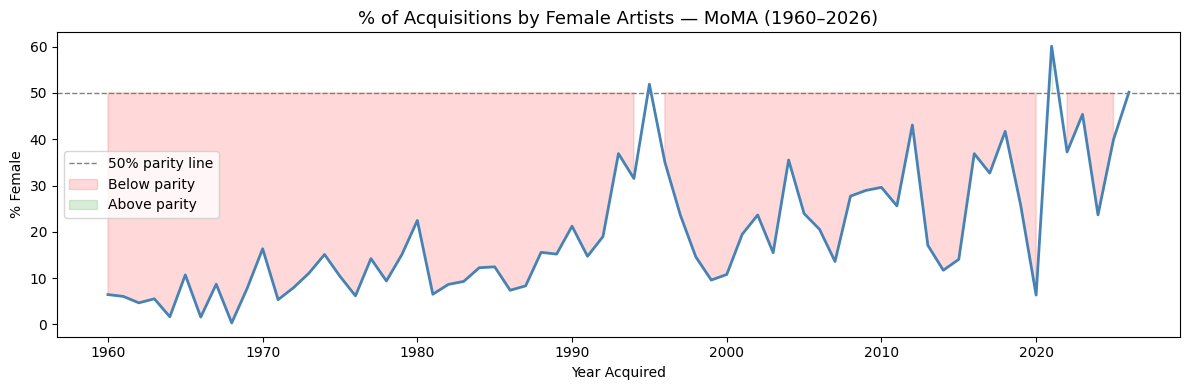

In [6]:
# ---- CHART 1: Female acquisition % over time ----
# ---- CHART 1: Gender (unchanged, already looks great) ----
gender_year = df[df['YearAcquired'] >= 1960].copy()
gender_year = gender_year[gender_year['Gender'].isin(['male', 'female'])]
gender_pivot = gender_year.groupby(['YearAcquired', 'Gender']).size().unstack(fill_value=0)
gender_pivot['female_pct'] = gender_pivot['female'] / (gender_pivot['female'] + gender_pivot['male']) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gender_pivot.index, gender_pivot['female_pct'], color='steelblue', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% parity line')
ax.fill_between(gender_pivot.index, gender_pivot['female_pct'], 50,
                where=(gender_pivot['female_pct'] < 50), alpha=0.15, color='red', label='Below parity')
ax.fill_between(gender_pivot.index, gender_pivot['female_pct'], 50,
                where=(gender_pivot['female_pct'] >= 50), alpha=0.15, color='green', label='Above parity')
ax.set_title("% of Acquisitions by Female Artists — MoMA (1960–2026)", fontsize=13)
ax.set_ylabel("% Female")
ax.set_xlabel("Year Acquired")
ax.legend()
plt.tight_layout()
plt.savefig('chart1_gender.png', dpi=150)
plt.show()

### 3.2 Nationality Distribution

In [7]:
# 2. Top nationalities
print("\nTop 15 Nationalities:")
print(df['Nationality'].value_counts().head(15))


Top 15 Nationalities:
Nationality
American               75343
French                 23013
German                  9747
British                 5739
Spanish                 3380
Italian                 3017
Japanese                2520
Russian                 2170
Swiss                   2127
American) (American     1638
Dutch                   1638
Mexican                 1631
Belgian                 1480
Argentine                948
Brazilian                940
Name: count, dtype: int64


In [8]:
# Fix dirty nationality duplicates
df['Nationality'] = df['Nationality'].str.replace(r'\(.*?\)', '', regex=True).str.strip()
df['Nationality'] = df['Nationality'].replace('', pd.NA)

print(df['Nationality'].value_counts().head(15))

Nationality
American               75343
French                 23013
German                  9747
British                 5739
Spanish                 3380
Italian                 3017
Japanese                2520
Russian                 2170
Swiss                   2127
American) (American     1638
Dutch                   1638
Mexican                 1631
Belgian                 1480
Argentine                948
Brazilian                940
Name: count, dtype: int64


In [9]:
# Fix nationality cleaning more aggressively
df['Nationality'] = df['Nationality'].str.replace(r'\(.*', '', regex=True).str.strip()
df['Nationality'] = df['Nationality'].replace('', pd.NA)

# Verify it worked
print(df['Nationality'].value_counts().head(15))

Nationality
American     75343
French       23013
German        9747
British       5739
Spanish       3380
Italian       3017
American)     3013
Japanese      2520
Russian       2170
Swiss         2127
Dutch         1638
Mexican       1631
Belgian       1480
Argentine      948
Brazilian      940
Name: count, dtype: int64


In [10]:
# Nuclear option for nationality cleaning
df['Nationality'] = df['Nationality'].str.replace(r'[()]', '', regex=True).str.strip()
df['Nationality'] = df['Nationality'].replace('', pd.NA)

# Merge any remaining "American" variants
df['Nationality'] = df['Nationality'].str.strip(')')

print(df['Nationality'].value_counts().head(15))

Nationality
American     78356
French       23444
German       10160
British       6267
Spanish       3422
Italian       3279
Japanese      2718
Russian       2551
Swiss         2338
Dutch         1769
Mexican       1705
Belgian       1607
Argentine     1188
Austrian      1068
Brazilian      974
Name: count, dtype: int64


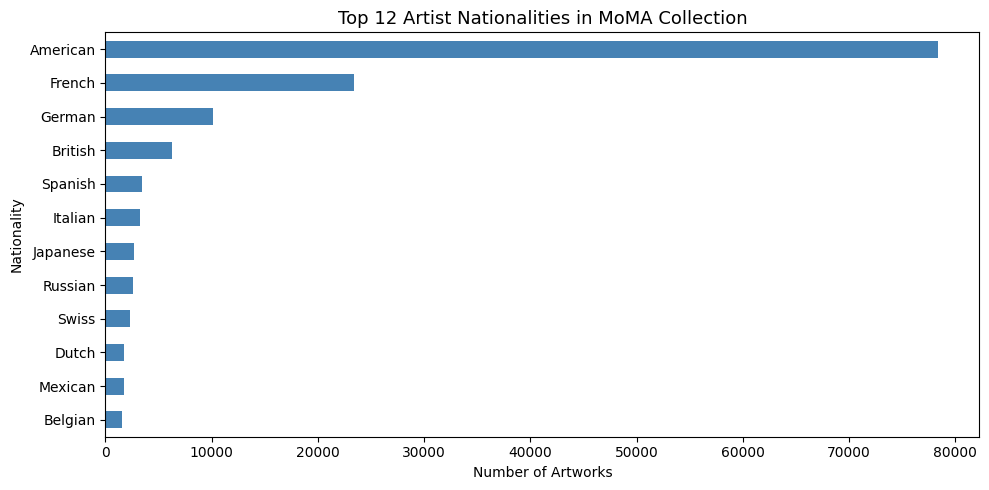

In [11]:
# ---- CHART 2: Top 12 nationalities (cleaned) ----
top_nat = df['Nationality'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
top_nat.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 12 Artist Nationalities in MoMA Collection", fontsize=13)
ax.set_xlabel("Number of Artworks")
plt.tight_layout()
plt.savefig('chart2_nationality.png', dpi=150)
plt.show()

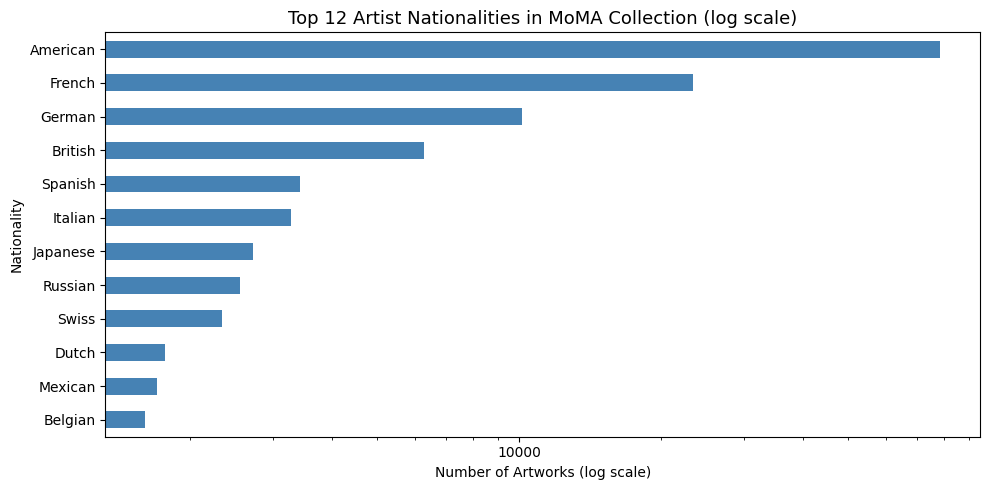

In [12]:
# ---- CHART 2: Top 12 nationalities — log scale to handle American dominance ----
top_nat = df['Nationality'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
top_nat.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xscale('log')
ax.set_title("Top 12 Artist Nationalities in MoMA Collection (log scale)", fontsize=13)
ax.set_xlabel("Number of Artworks (log scale)")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.savefig('chart2_nationality.png', dpi=150)
plt.show()

### 3.3 Acquisition Spikes & Bulk Donations

In [13]:
# 3. Department acquisition trend
dept_year = df[df['YearAcquired'] >= 1930].groupby(['YearAcquired', 'Department']).size().unstack(fill_value=0)
print("\nDepartments:")
print(dept_year.tail(5))


Departments:
Department    Architecture & Design  Drawings & Prints  Film  \
YearAcquired                                                   
2022.0                           37               1072    35   
2023.0                          131                126     7   
2024.0                          324                598     6   
2025.0                          271                370     0   
2026.0                          204                148     0   

Department    Fluxus Collection  Media and Performance  Painting & Sculpture  \
YearAcquired                                                                   
2022.0                        0                     36                    54   
2023.0                        0                     45                    28   
2024.0                        0                    122                    60   
2025.0                        0                     59                    32   
2026.0                        0                     20   

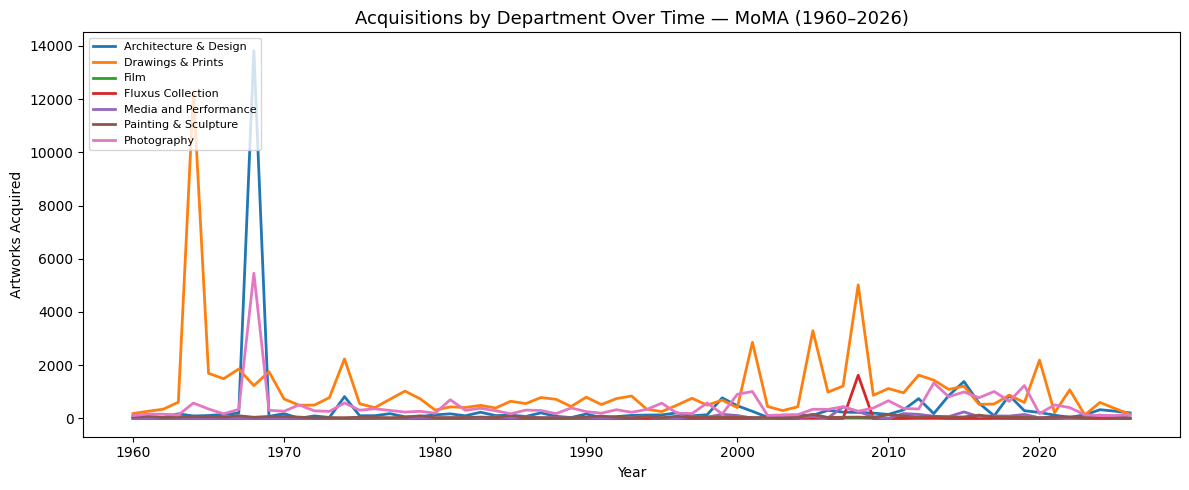

In [14]:
# ---- CHART 3: Department acquisitions over time ----
dept_year = df[df['YearAcquired'] >= 1960].groupby(['YearAcquired', 'Department']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
dept_year.plot(ax=ax, linewidth=2)
ax.set_title("Acquisitions by Department Over Time — MoMA (1960–2026)", fontsize=13)
ax.set_ylabel("Artworks Acquired")
ax.set_xlabel("Year")
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('chart3_departments.png', dpi=150)
plt.show()

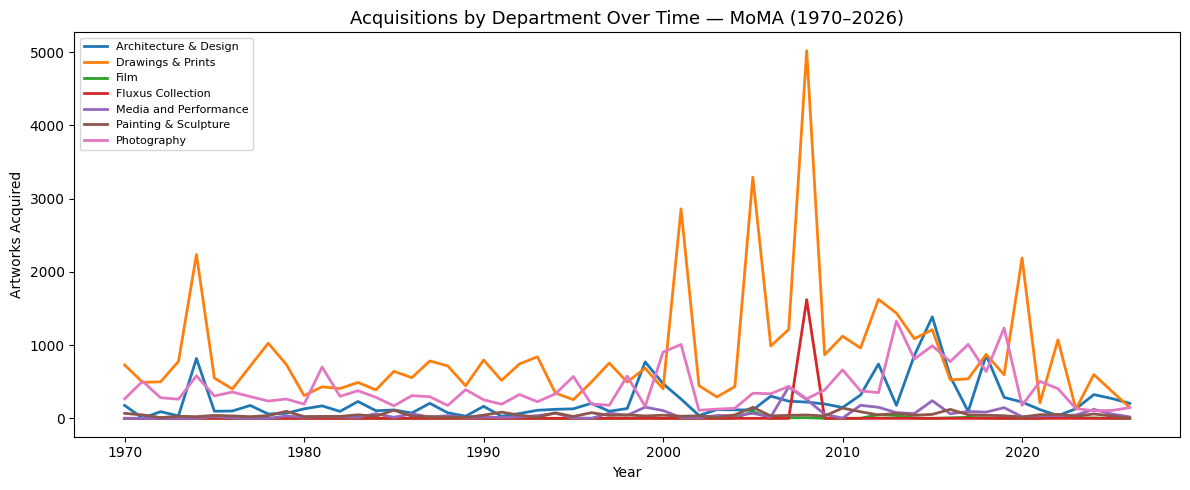

In [15]:
# ---- CHART 3: Departments from 1970 to avoid the giant 60s spike ----
dept_year = df[(df['YearAcquired'] >= 1970)].groupby(['YearAcquired', 'Department']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
dept_year.plot(ax=ax, linewidth=2)
ax.set_title("Acquisitions by Department Over Time — MoMA (1970–2026)", fontsize=13)
ax.set_ylabel("Artworks Acquired")
ax.set_xlabel("Year")
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('chart3_departments.png', dpi=150)
plt.show()

In [16]:
# What's driving the Drawings & Prints spike?
spike = df[
    (df['Department'] == 'Drawings & Prints') &
    (df['YearAcquired'] >= 2005) &
    (df['YearAcquired'] <= 2012)
]

print(spike.groupby('YearAcquired').size())
print("\nTop artists in that period:")
print(spike['Artist'].value_counts().head(10))

YearAcquired
2005.0    3292
2006.0     987
2007.0    1214
2008.0    5018
2009.0     867
2010.0    1121
2011.0     960
2012.0    1624
dtype: int64

Top artists in that period:
Artist
Louise Bourgeois               2101
George Maciunas                 408
José Antonio Suárez Londoño     285
Alighiero Boetti                278
Ben Vautier                     232
León Ferrari                    217
Thomas Schütte                  205
Robert Watts                    201
Aleksandra Mir                  175
George Brecht                   170
Name: count, dtype: int64


In [17]:
# Confirm Louise Bourgeois spike year
print(df[df['Artist'] == 'Louise Bourgeois']['YearAcquired'].value_counts().sort_index())

YearAcquired
1947.0      10
1951.0       1
1968.0       1
1969.0       1
1970.0       1
1982.0       1
1983.0       1
1986.0       2
1990.0     139
1991.0       1
1992.0      91
1993.0     319
1994.0      77
1995.0      13
1996.0     153
1997.0     103
1998.0      17
1999.0      32
2000.0      38
2001.0       7
2002.0      49
2005.0     102
2006.0      55
2007.0       1
2008.0    1055
2009.0     120
2010.0     123
2011.0      77
2012.0     568
2013.0      40
2014.0       1
2016.0      26
2018.0      12
Name: count, dtype: int64


In [18]:
# What's actually driving 2008?
print(df[(df['Department'] == 'Drawings & Prints') & (df['YearAcquired'] == 2008)]['Artist'].value_counts().head(10))

Artist
Louise Bourgeois    1055
George Maciunas      406
Ben Vautier          232
Robert Watts         198
George Brecht        170
Milan Knížák         154
Philip Corner        109
Nam June Paik         69
Mieko Shiomi          65
Robert Filliou        61
Name: count, dtype: int64


## 4. Key Findings & Recommendations

In [19]:
# A few final numbers to quote in your summary
print("Total artworks:", len(df))
print("Years covered:", int(df['YearAcquired'].min()), "–", int(df['YearAcquired'].max()))

# Female % in 1960s vs recent
early = df[(df['YearAcquired'] >= 1960) & (df['YearAcquired'] <= 1969) & df['Gender'].isin(['male','female'])]
recent = df[(df['YearAcquired'] >= 2015) & df['Gender'].isin(['male','female'])]

early_pct = (early['Gender'] == 'female').mean() * 100
recent_pct = (recent['Gender'] == 'female').mean() * 100

print(f"Female % 1960s: {early_pct:.1f}%")
print(f"Female % 2015–2026: {recent_pct:.1f}%")

# American dominance
american_pct = (df['Nationality'] == 'American').sum() / df['Nationality'].notna().sum() * 100
print(f"American artists % of collection: {american_pct:.1f}%")

Total artworks: 160597
Years covered: 1929 – 2026
Female % 1960s: 2.4%
Female % 2015–2026: 28.1%
American artists % of collection: 51.1%


## Executive Summary

**To:** MoMA Board of Trustees  
**Re:** Acquisition Trends Analysis — MoMA Permanent Collection (1929–2026)

---

### Finding 1: Gender Representation Has Improved, But Remains Far From Parity
Female artists represented just **2.4% of acquisitions in the 1960s**. By 2015–2026, that figure rose to **28.1%** — a significant shift, but still well below proportional representation. Notably, 2021 marked the first year female artists exceeded 50% of acquisitions, suggesting intentional curatorial effort. However, year-to-year volatility indicates this progress is not yet institutionalized.

**Recommendation:** Establish a formal gender equity acquisition target (e.g. 40% female artists by 2030) and track it annually as a KPI.

---

### Finding 2: The Collection Remains Geographically Concentrated
American artists account for **51.1% of all works** in the collection. French artists are a distant second at 14.6%. Artists from the Global South — Latin America, Africa, Southeast Asia — represent a small fraction of the total collection despite growing curatorial interest in recent years.

**Recommendation:** Develop a targeted acquisition strategy for underrepresented geographies, with dedicated budget allocation and regional advisory partnerships.

---

### Finding 3: Bulk Donations Drive Acquisition Spikes, Not Steady Strategy
The 2008 spike of 5,018 Drawings & Prints acquisitions was driven almost entirely by two bulk gifts: ~1,055 Louise Bourgeois works and ~1,400 Fluxus collection pieces. This pattern repeats throughout the collection's history. Over-reliance on bulk donations creates an uneven, donor-driven collection narrative.

**Recommendation:** Balance opportunistic bulk acquisitions with a proactive annual acquisition plan that fills identified gaps in gender, nationality, and medium representation.

---

### Conclusion
MoMA's collection reflects both the progress and the limitations of 20th century institutional collecting. The data points to a clear opportunity: a more intentional, metrics-driven acquisition strategy could meaningfully diversify the collection over the next decade without sacrificing the curatorial excellence MoMA is known for.